<a href="https://colab.research.google.com/github/fluorescentlightpower/mifi_homework/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22Homework_with_answers_modul_2_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задача: Анализ эффективности нового алгоритма рекомендаций в условиях асимметричного и зашумленного распределения
### Контекст:
Крупная стриминговая платформа (аналог YouTube или Twitch) разработала новый алгоритм рекомендаций контента (алгоритм B), который, как ожидается, должен увеличить среднее время просмотра на пользователя по сравнению со старым алгоритмом (A).

Было проведено A/B-тестирование:

- **Группа A (Контрольная)**: 5000 пользователей, старый алгоритм.

- **Группа B (Тестовая)**: 5000 пользователей, новый алгоритм.

По итогам двухнедельного теста вы собрали данные по ключевой метрике — **«Общее время просмотра на пользователя за тест (в минутах)»**.

**Данные и их особенности:**

**Не нормальность:** Распределение метрики в обеих группах сильно отличается от нормального. Оно имеет типичный для поведенческих данных "длинный хвост":

- Большинство пользователей смотрят немного (пик в районе 0-50 минут).

- Небольшая группа "супер-зрителей" смотрит очень много (сотни и тысячи минут), формируя длинный правый хвост распределения.

**Асимметрия влияния:** Новый алгоритм B целенаправленно меняет опыт именно активных пользователей, в то время как для "пассивных" зрителей разница неочевидна. Это означает, что различие между группами может быть не сдвигом всего распределения, а изменением в правом хвосте.

**Наличие выбросов:** В данных присутствуют экстремальные выбросы (например, пользователи, которые оставляли видео фоном на всю ночь).

Вам предоставлен датасет _ab_test_results.csv_ со следующими колонками:

 - _user_id_

 - _group (A или B)_

 - _total_watch_time_min_

### Задания:


- **Проведите тест Манна-Уитни (Mann-Whitney U test)**. Сформулируйте нулевую и альтернативную гипотезы. Интерпретируйте p-value. Можно ли на его основе сделать однозначный вывод о превосходстве алгоритма B?

- Чтобы исследовать "асимметричное влияние", проведите анализ разниц не только в центре распределения, но и в хвостах. **Рассчитайте и визуализируйте разницу между группами для 75-го, 90-го и 95-го процентилей**.

- **Сформулируйте итоговый вывод:**

    - Эффективен ли новый алгоритм B?

    - На какую именно группу пользователей он оказывает наибольшее влияние?

    - Какой метод анализа оказался наиболее информативным в данном случае и почему?

    - Дайте рекомендацию о возможности запуска алгоритма на всю аудиторию.



In [7]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import gdown
import matplotlib.pyplot as plt

Downloading...
From: https://drive.google.com/uc?id=1mi0UGHUVEhYALWKrmoSZy0yPaCqLOu5U
To: /content/ab_test_results.csv
100%|██████████| 311k/311k [00:00<00:00, 47.8MB/s]

Dataset Summary:
Total users: 10000
Group A: 5000 users
Group B: 5000 users

Descriptive Statistics by Group:


,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A,5000.0,56.347878,262.313288,0.0,14.729144,26.834960,44.946309,8130.547119
B,5000.0,71.477408,408.519252,0.0,15.383838,27.352416,46.352279,11670.621483



Key Percentiles by Group:
50th percentile: A=26.8, B=27.4, Difference=0.5
75th percentile: A=44.9, B=46.4, Difference=1.4
90th percentile: A=71.5, B=76.2, Difference=4.7
95th percentile: A=119.3, B=153.6, Difference=34.3


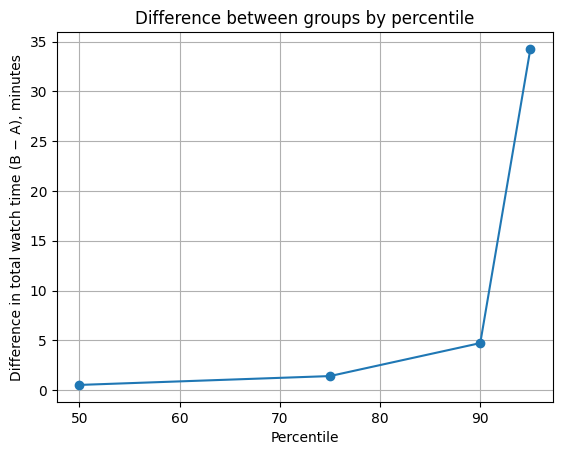


Mann-Whitney U Test: p-value = 0.022671


In [10]:
# Load CSV
url = 'https://drive.google.com/uc?id=1mi0UGHUVEhYALWKrmoSZy0yPaCqLOu5U'
gdown.download(url, 'ab_test_results.csv', quiet=False)
df = pd.read_csv('ab_test_results.csv') # ab_test_results.csv from the SF site link

group_a_data = df[df['group'] == 'A']['total_watch_time_min']
group_b_data = df[df['group'] == 'B']['total_watch_time_min']

# Display summary statistics
print("Dataset Summary:")
print(f"Total users: {len(df)}")
print(f"Group A: {len(group_a_data)} users")
print(f"Group B: {len(group_b_data)} users")
print("\nDescriptive Statistics by Group:")
display(df.groupby('group')['total_watch_time_min'].describe())

print("\nKey Percentiles by Group:")
percentiles = [0.50, 0.75, 0.9, 0.95]
p_labels = []
diffs = []
for p in percentiles:
    p_val = p * 100
    a_val = np.percentile(group_a_data, p_val)
    b_val = np.percentile(group_b_data, p_val)
    diff = b_val - a_val
    p_labels.append(int(p_val))
    diffs.append(diff)
    print(f"{p_val:.0f}th percentile: A={a_val:.1f}, B={b_val:.1f}, Difference={diff:.1f}")

# Plot the A/B differences per percentile
plt.figure()
plt.plot(p_labels, diffs, marker='o')
plt.grid()

plt.xlabel("Percentile")
plt.ylabel("Difference in total watch time (B − A), minutes")
plt.title("Difference between groups by percentile")

plt.show()

# Test the differences
mw_stat, mw_p = stats.mannwhitneyu(
    group_a_data,
    group_b_data,
    alternative= 'less'
)

print(f"\nMann-Whitney U Test: p-value = {mw_p:.6f}")

$T_A$ — общее время просмотра пользователя из группы A (старый алгоритм),

$T_A$ — общее время просмотра пользователя из группы B (новый алгоритм).

Нулевая гипотеза ($H_0$):
распределения времени просмотра в группах A и B одинаковы;
вероятность того, что пользователь из B смотрит больше, чем пользователь из A, равна 0,5.

$$
H_0: P(T_B > T_A) = 0,5
$$

Альтернативная гипотеза, односторонняя ($H_1$):
распределение времени просмотра в группе B стохастически смещено вправо относительно группы A;
вероятность того, что пользователь из B смотрит больше, чем пользователь из A, больше 0,5.

$$
H_1: P(T_B > T_A) > 0,5
$$

Результаты теста Манна-Уитни выражается $p$-$value = 0,0227$

При уровне значимости $\alpha = 0,05$ нулевая гипотеза отвергается, наблюдаемая разница между группами статистически значима. Есть статистически значимые основания утверждать, что пользователь с новым алгоритмом B чаще имеет большее время просмотра, чем пользователь со старым алгоритмом A. Отсюда не следует соотношение между средними или медианами, но есть ранговое (вероятностное) превосходство. Таким образом, нет оснований сделать однозначный вывод о превосходстве алгоритма B. Необходим анализ размера эффекта, в том числе с точки зрения значимости для бизнеса, и других метрик.

Анализ различий по процентилям (асимметричное влияние)

| Метрика       | A     | B     | Комментарий             |
| ------------- | ----- | ----- | ----------------------- |
| 50% (медиана) | 26,8  | 27,4  | Почти нет эффекта       |
| 75%           | 44,9  | 46,4  | Малый сдвиг             |
| 90%           | 71,5  | 76,2  | Умеренный сдвиг         |
| 95%           | 119,3 | 153,6 | Сильный эффект в хвосте |

До 75-го процентиля разница минимальна, в области 90–95 перцентилей эффект резко усиливается, основной вклад в рост времени просмотра формируется в правом хвосте распределения. Это полностью соответствует гипотезе о механизме действия алгоритма B.

Отсюда следует, что новый алгоритм B не меняет существенно поведение пассивных пользователей, значимо увеличивает вовлечённость активных пользователей,приводит к росту среднего времени просмотра за счёт усиления хвоста. Рост среднего значения (с 56 до 71 мин) подтверждает направление эффекта,
но не является убедительным из-за чувствительности к выбросам.

Алгоритм B оказывает наибольшее влияние на активных пользователей, верхние $~5-10\%$ распределения по времени просмотра.

Для пользователей с низкой и средней активностью эффект минимален, поведение практически не меняется.

Наиболее информативным является тест Манна–Уитни в сочетании с анализом процентилей, так как распределение сильно ненормальное, с длинным хвостом;эффект не выражается равномерным сдвигом; данный тест устойчив к выбросам;анализ процентилей позволяет локализовать эффект (показать, где именно он возникает). Среднее было бы плохим индикатором, так как чувствительно к выбросам и не отражает характер эффекта (проявляется больше всего в хвосте распределения)

Рекомендации по запуску алгоритма B:
эффект статистически значим;
направление эффекта соответствует ожиданиям;
риск ложноположительного вывода невысок.

Рекомендутеся запуск алгоритма B. Если необходима максимизация общего времени просмотра, предпочтителен полный запуск сразу. Возможен вариант постепенного расширения области алгоритма B, начиная с наиболее активных пользователей.
